### Описание задания 1
##### Найдите данные (возможные варианты будут лежать ниже), дать ссылку на источник и предоставить описание переменных (так, как это было сделано на занятии).
Требования к данным следующие:
· >= 100 наблюдений;
· должны присутствовать хотя бы 3 числовые и 1 категориальная переменная;
· вам должно быть интересно их исследовать:)

##### Выполните предобработку:
- проведите первичный анализ: общая консистентность, соответствие типов колонок заявленным, наличие пропущенных значений, дубликатов, других странностей;
- исследуйте пропущенные значения (если есть);
- выполните необходимые преобразования, если потребуется;

##### Изучите каждую переменную согласно ее типу (как первично так и углубленно):
- посчитайте подходящие метрики;
- постройте соответствующие графики;

##### Изучите взаимодействие переменных:
- среди взаимодействующих пар должно быть хотя бы 2 из 6 обозначенных на занятии типов (например: числовая & числовая и числовая & категориальная);
- нужна постановка исследовательского вопроса (для каждой пары);
- обязательны метрики и графики для каждой пары.

##### Также в работе нужно:
- использовать groupby и затем agg и / или apply;
- бонусом будет, если вы найдете датасет, который можно будет присоединить к текущему с использованием merge;
- все ваши шаги должны сопровождаться пояснениями и описанием (в разумных пределах: достаточно описывать в общем, если конечно не нужно подчеркнуть частности. Можно ориентироваться на семинарские ноутбуки).

##### Инструменты для выполнения ДЗ
- Python.
- Библиотека NumPy — для работы с массивами и выполнения математических операций.
- Библиотека Pandas — для работы с табличными данными, их обработки и анализа.
- Библиотека Matplotlib — для создания базовых графиков.
- Библиотека Seaborn — для расширенной визуализации данных и построения статистических графиков.
- Библиотека Plotly (по желанию) — для интерактивной визуализации данных.

- Функции groupby, agg, apply, pivot, melt, merge из Pandas.
- Jupyter Notebook — для оформления работы, написания кода и пояснительных комментариев с использованием Markdown

##### Правила приёма работы Правила приёма работы:

Работа принимается в формате Jupyter Notebook (.ipynb).

Весь код должен быть корректно выполнен и воспроизводим без ошибок.

Все этапы решения должны сопровождаться пояснительным текстом с описанием проделанных шагов и выводами. Использование ячеек Markdown обязательно.

В работе должны быть соблюдены все требования, указанные в описании задания:
· выбран и корректно оформлен источник данных;
· выполнена первичная обработка данных с анализом пропусков, дубликатов и типов данных;
· представлен анализ каждой переменной (метрики и визуализация);
· выполнен анализ взаимодействия переменных (минимум 4 типа связей);
· в коде использованы библиотеки NumPy, Pandas, инструменты группировки и преобразования данных;
· продемонстрировано использование векторизации, а также хотя бы одной новой функции из библиотек, не изученной на занятиях.

Отсутствие любого из обязательных пунктов (кроме пояснений) влечёт вычитание 1 балла за каждый пропуск.

Отсутствие пояснений и обоснований к выполненным шагам приведёт к снижению оценки на 50%.

Работа сдана в срок, установленный преподавателем.

Дополнительные 2 балла начисляются за поиск и присоединение к основному датасету дополнительного набора данных с помощью функции merge.

Проверяющий оставляет за собой право снизить балл за недостаточный объём или качество выполнения любого пункта

## Анализ потребления электроэнергии и проверка переходящего сальдо

- В ДЗ будут использоваться файлы с реальными данными о потреблении электроэнергии. Файлы разделены на районы.
- В моей деятельности требуется обычно объединить эти файлы и сверять данные бухгалтерских величин (сальдо, задолженность, и т.д.), а так же потребление ЭЭ физическими лицамии в разрезе районов и целого города.
- Для ДЗ буду анализировать и визуализировать следующие данные: услуга электроэнергии


## Цели анализа

1. **Объединение данных**

   Собрать все файлы в единый DataFrame, добавив колонку-идентификатор района.

2. **Проверка данных на отсутствие дубликатов и пропуски (предобработка)**

   Проверить корректность данных по сальдо, задолженности, соответствие оплат и начислений.

3. **Анализ потребления ЭЭ**

   - По физическим лицам
   - В разрезе районов
   - Процент ошибок в лицевых счетах при закрытии прошлого расчетного периода и открытии нового расчетного периода

4. **Визуализация**

   Построить графики:
   - Сравнение районов по ошибочным ЛС

In [1]:
# импорт необходимых инструментов
import pandas as pd # основная библиотека для табличных данных
import numpy as np # математические операции, массивы, линейная алгебра
import datetime as datetime # работа с датами и временем
import matplotlib.pyplot as plt # низкоуровневая графика, гибкий контроль
import seaborn as sns # статистическая визуализация
import missingno # модуль позволяет смотреть пропущенные значения по всему файлу

### Импорт файлов, необходимых для работы

In [2]:
#предыдущий месяц
df_v_z_last = pd.read_csv('C:\\Users\\User\\Desktop\\питон\\пред мес\\3.2. ДЗ_Восточное_Западное отделение.csv', sep=';', encoding='utf-8', dtype={'Номер договора': str})
df_cao_1_2_last = pd.read_csv('C:\\Users\\User\\Desktop\\питон\\пред мес\\3.2. ДЗ_ЦАО1_ЦАО2.csv', sep=';', encoding='utf-8', dtype={'Номер договора': str})
df_s_y_last = pd.read_csv('C:\\Users\\User\\Desktop\\питон\\пред мес\\3.2. ДЗ_Северное_Южное отделение.csv', sep=';', encoding='utf-8', dtype={'Номер договора': str})


**Проверка типа данных в файлах**

In [3]:
df_v_z_last.info()

<class 'pandas.DataFrame'>
RangeIndex: 712882 entries, 0 to 712881
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Месяц года                712882 non-null  float64
 1   Номер договора            712882 non-null  str    
 2   Id договора               712882 non-null  str    
 3   Код услуги                712882 non-null  str    
 4   Вид начисления            712882 non-null  str    
 5   ДЗ на начало периода      484107 non-null  str    
 6   КЗ на начало периода      228879 non-null  str    
 7   ДЗ на конец периода       484107 non-null  str    
 8   КЗ на конец периода       228879 non-null  str    
 9   состояние расчетов        712882 non-null  str    
 10  Договорное подразделение  712882 non-null  str    
 11  Расчетное подразделение   712882 non-null  str    
 12  Поставщик                 222066 non-null  str    
dtypes: float64(1), str(12)
memory usage: 70.7 MB


In [4]:
df_cao_1_2_last.info()

<class 'pandas.DataFrame'>
RangeIndex: 1093746 entries, 0 to 1093745
Data columns (total 13 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Месяц года                1093746 non-null  float64
 1   Номер договора            1093746 non-null  str    
 2   Id договора               1093746 non-null  str    
 3   Код услуги                1093746 non-null  str    
 4   Вид начисления            1093746 non-null  str    
 5   ДЗ на начало периода      826236 non-null   str    
 6   КЗ на начало периода      267718 non-null   str    
 7   ДЗ на конец периода       826236 non-null   str    
 8   КЗ на конец периода       267718 non-null   str    
 9   состояние расчетов        1093746 non-null  str    
 10  Договорное подразделение  1093746 non-null  str    
 11  Расчетное подразделение   1093746 non-null  str    
 12  Поставщик                 405241 non-null   str    
dtypes: float64(1), str(12)
memory usage: 1

In [5]:
df_s_y_last.info()

<class 'pandas.DataFrame'>
RangeIndex: 824251 entries, 0 to 824250
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Месяц года                824251 non-null  float64
 1   Номер договора            824251 non-null  str    
 2   Id договора               824251 non-null  str    
 3   Код услуги                824251 non-null  str    
 4   Вид начисления            824251 non-null  str    
 5   ДЗ на начало периода      563611 non-null  str    
 6   КЗ на начало периода      260801 non-null  str    
 7   ДЗ на конец периода       563611 non-null  str    
 8   КЗ на конец периода       260801 non-null  str    
 9   состояние расчетов        824251 non-null  str    
 10  Договорное подразделение  824251 non-null  str    
 11  Расчетное подразделение   824251 non-null  str    
 12  Поставщик                 274233 non-null  str    
dtypes: float64(1), str(12)
memory usage: 81.8 MB


In [6]:
#текущий месяц
df_v_z_current = pd.read_csv('C:\\Users\\User\\Desktop\\питон\\тек мес\\3.2. ДЗ_Восточное_Западное отделение.csv', sep=';', encoding='utf-8', dtype={'Номер договора': str})
df_cao_1_2_current  = pd.read_csv('C:\\Users\\User\\Desktop\\питон\\тек мес\\3.2. ДЗ_ЦАО1_ЦАО2.csv', sep=';', encoding='utf-8', dtype={'Номер договора': str})
df_s_y_current = pd.read_csv('C:\\Users\\User\\Desktop\\питон\\тек мес\\3.2. ДЗ_Северное_Южное отделение.csv', sep=';', encoding='utf-8', dtype={'Номер договора': str})

In [7]:
df_v_z_current.info()

<class 'pandas.DataFrame'>
RangeIndex: 712882 entries, 0 to 712881
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Месяц года                712882 non-null  float64
 1   Номер договора            712882 non-null  str    
 2   Id договора               712882 non-null  str    
 3   Код услуги                712882 non-null  str    
 4   Вид начисления            712882 non-null  str    
 5   ДЗ на начало периода      484107 non-null  str    
 6   КЗ на начало периода      228879 non-null  str    
 7   ДЗ на конец периода       484107 non-null  str    
 8   КЗ на конец периода       228879 non-null  str    
 9   состояние расчетов        712882 non-null  str    
 10  Договорное подразделение  712882 non-null  str    
 11  Расчетное подразделение   712882 non-null  str    
 12  Поставщик                 222066 non-null  str    
dtypes: float64(1), str(12)
memory usage: 70.7 MB


In [8]:
df_cao_1_2_current.info()

<class 'pandas.DataFrame'>
RangeIndex: 1093746 entries, 0 to 1093745
Data columns (total 13 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Месяц года                1093746 non-null  float64
 1   Номер договора            1093746 non-null  str    
 2   Id договора               1093746 non-null  str    
 3   Код услуги                1093746 non-null  str    
 4   Вид начисления            1093746 non-null  str    
 5   ДЗ на начало периода      826236 non-null   str    
 6   КЗ на начало периода      267718 non-null   str    
 7   ДЗ на конец периода       826236 non-null   str    
 8   КЗ на конец периода       267718 non-null   str    
 9   состояние расчетов        1093746 non-null  str    
 10  Договорное подразделение  1093746 non-null  str    
 11  Расчетное подразделение   1093746 non-null  str    
 12  Поставщик                 405241 non-null   str    
dtypes: float64(1), str(12)
memory usage: 1

In [9]:
df_s_y_current.info()

<class 'pandas.DataFrame'>
RangeIndex: 824251 entries, 0 to 824250
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Месяц года                824251 non-null  float64
 1   Номер договора            824251 non-null  str    
 2   Id договора               824251 non-null  str    
 3   Код услуги                824251 non-null  str    
 4   Вид начисления            824251 non-null  str    
 5   ДЗ на начало периода      563611 non-null  str    
 6   КЗ на начало периода      260801 non-null  str    
 7   ДЗ на конец периода       563611 non-null  str    
 8   КЗ на конец периода       260801 non-null  str    
 9   состояние расчетов        824251 non-null  str    
 10  Договорное подразделение  824251 non-null  str    
 11  Расчетное подразделение   824251 non-null  str    
 12  Поставщик                 274233 non-null  str    
dtypes: float64(1), str(12)
memory usage: 81.8 MB


### Соединяю таблицы по строкам, чтобы потом выделить уникальные значения по районам для дальнейшего анализа

In [10]:
#предыдущий месяц

last = pd.concat([df_v_z_last,
                  df_cao_1_2_last,
                  df_s_y_last], ignore_index=True)

#текущий месяц

current = pd.concat([df_v_z_current,
                     df_cao_1_2_current,
                     df_s_y_current], ignore_index=True)

In [11]:
last.info()

<class 'pandas.DataFrame'>
RangeIndex: 2630879 entries, 0 to 2630878
Data columns (total 13 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Месяц года                float64
 1   Номер договора            str    
 2   Id договора               str    
 3   Код услуги                str    
 4   Вид начисления            str    
 5   ДЗ на начало периода      str    
 6   КЗ на начало периода      str    
 7   ДЗ на конец периода       str    
 8   КЗ на конец периода       str    
 9   состояние расчетов        str    
 10  Договорное подразделение  str    
 11  Расчетное подразделение   str    
 12  Поставщик                 str    
dtypes: float64(1), str(12)
memory usage: 260.9 MB


In [12]:
current.info()

<class 'pandas.DataFrame'>
RangeIndex: 2630879 entries, 0 to 2630878
Data columns (total 13 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Месяц года                float64
 1   Номер договора            str    
 2   Id договора               str    
 3   Код услуги                str    
 4   Вид начисления            str    
 5   ДЗ на начало периода      str    
 6   КЗ на начало периода      str    
 7   ДЗ на конец периода       str    
 8   КЗ на конец периода       str    
 9   состояние расчетов        str    
 10  Договорное подразделение  str    
 11  Расчетное подразделение   str    
 12  Поставщик                 str    
dtypes: float64(1), str(12)
memory usage: 260.9 MB


<Axes: >

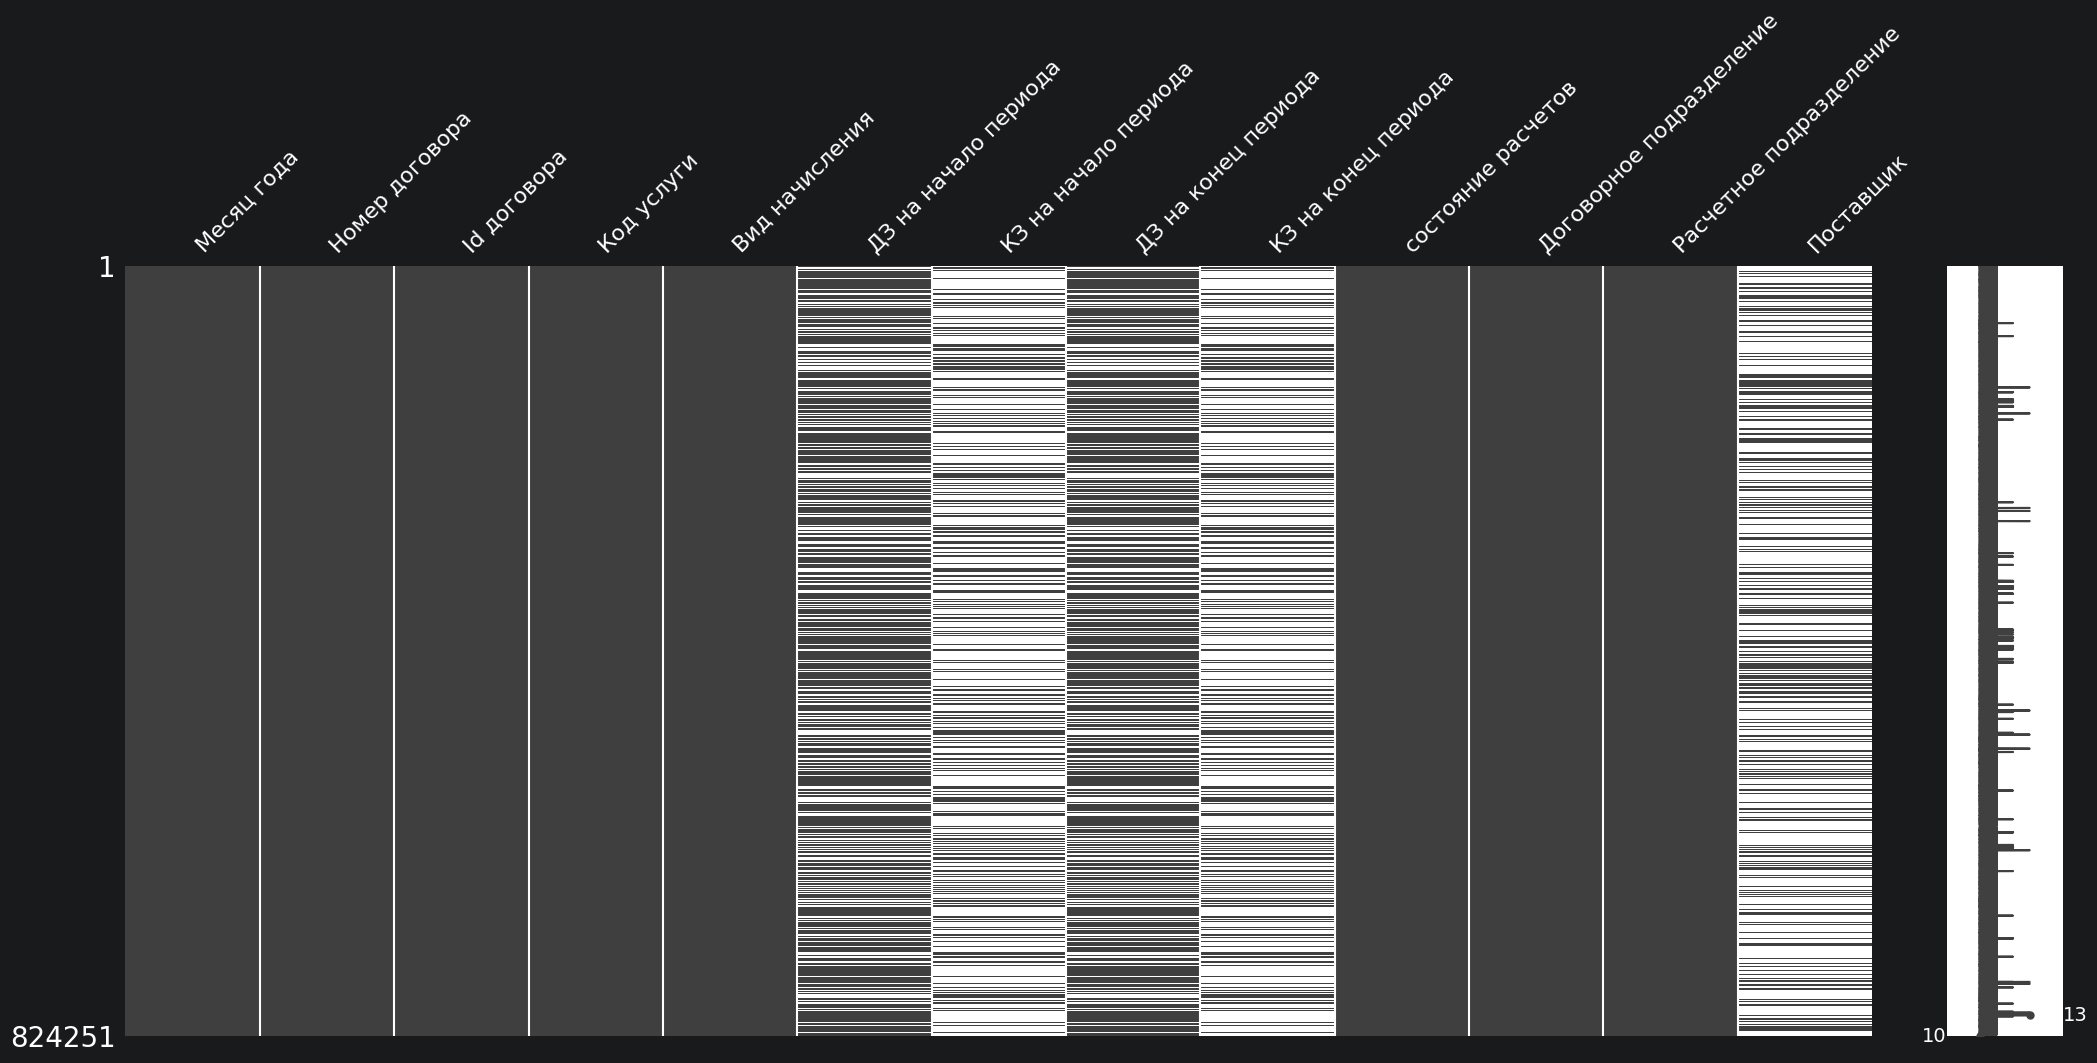

In [13]:
# визуализация пропуска в данных
missingno.matrix(df_s_y_current)

##### Выполните предобработку:
- проведите первичный анализ: общая консистентность, соответствие типов колонок заявленным, наличие пропущенных значений, дубликатов, других странностей; _- в файлах присутствуют дубликаты, т.к. несколько ЖКХ услуг есть на одном договоре. **Чтобы понимать всю картину по ЭЭ, нужно будет сложить данные по коду услуги EE**._
- исследуйте пропущенные значения (если есть) - _пропущенные значения присутствуют как в числовых данных так и в столбце "Поставщик"_
- выполните необходимые преобразования, если потребуется; - _необходимо преобразовать остутсвующие значения в числовых столбцах для дальнейших расчетов._

##### Изучите каждую переменную согласно ее типу (как первично так и углубленно):
- посчитайте подходящие метрики;
**- метрики, которые будут анализироваться: вид начисления - "ЭЭ", к этой ЖКХ услуге будут считаться ДЗ и КЗ на начало, ДЗ и КЗ на конец, разница между ДЗ есть начисление.**
- постройте соответствующие графики;

### Необходимо сделать столбцы 'ДЗ на начало периода', 'КЗ на начало периода', 'ДЗ на конец периода', 'КЗ на конец периода' из типа str во float и месяц в формат datetime


In [14]:
PEREHOD = ['ДЗ на начало периода', 'КЗ на начало периода', 'ДЗ на конец периода','КЗ на конец периода']

last[PEREHOD] = last[PEREHOD].apply(lambda col: col.str.replace(',', '.').astype(float))

In [15]:
current[PEREHOD] = current[PEREHOD].apply(lambda col: col.str.replace(',', '.').astype(float))

In [16]:
current.info()

<class 'pandas.DataFrame'>
RangeIndex: 2630879 entries, 0 to 2630878
Data columns (total 13 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Месяц года                float64
 1   Номер договора            str    
 2   Id договора               str    
 3   Код услуги                str    
 4   Вид начисления            str    
 5   ДЗ на начало периода      float64
 6   КЗ на начало периода      float64
 7   ДЗ на конец периода       float64
 8   КЗ на конец периода       float64
 9   состояние расчетов        str    
 10  Договорное подразделение  str    
 11  Расчетное подразделение   str    
 12  Поставщик                 str    
dtypes: float64(5), str(8)
memory usage: 260.9 MB


In [17]:
# создаем новый столбец с форматом даты, переводя столбец date из str в datetime
last['Месяц года'] = pd.to_datetime(last['Месяц года'].astype(str), format='%Y.%m')
current['Месяц года'] = pd.to_datetime(current['Месяц года'].astype(str), format='%Y.%m')

### Предобработка данных.

_Заполнение нулями столбцов "ДЗ на начало периода",	"КЗ на начало периода", "ДЗ на конец периода", "КЗ на конец периода"_

Это необходимо именно заполнить нулями, т.к. сводится бухгалтерский баланс для всех лицевых счетов, поэтому пропуски лучше не оставлять.

In [18]:
fill_values = {
    'ДЗ на начало периода': 0,
    'КЗ на начало периода': 0,
    'ДЗ на конец периода': 0,
    'КЗ на конец периода': 0,
    'состояние расчетов': 0
}

last = last.fillna(fill_values)
current = current.fillna(fill_values)

In [19]:
# проверка заполнения
current.sample(3)

,Месяц года,Номер договора,Id договора,Код услуги,Вид начисления,ДЗ на начало периода,КЗ на начало периода,ДЗ на конец периода,КЗ на конец периода,состояние расчетов,Договорное подразделение,Расчетное подразделение,Поставщик
2003956,2026-05-01,13401427691,0Z0SDLMTB9,HV,"переплата ХВС, Пени",0.00,-19.95,0.00,-19.95,"-19,95",Южное отделение для БФЛ,Омский УОК,NaN
1638452,2026-05-01,96012380999,AB6WUM63YK,MSS,"основная, Системы безопасности",-122.00,0.00,-122.00,0.00,-122,Договорной отдел г. Омск,1_Центрального АО физические лица,NaN
1411497,2026-05-01,86112851387,9SKRUE6MW6,TKO,"Обращение с ТКО, Льготный",157.33,0.00,157.33,0.00,"157,33",Договорной отдел г. Омск,2_Центрального АО физические лица,"ООО ""Магнит"""


### Делаю фильтр для датафрейма только по коду услуги EE и дальше буду работать с этим фреймом

In [20]:
#предыдущий месяц
last_ee = last[last['Код услуги'] == 'EE']

In [21]:
#текущий месяц
current_ee = current[current['Код услуги'] == 'EE']

### Список районов для анализа

In [22]:
#предыдущий месяц
last_district = last['Расчетное подразделение'].unique()

#текущий месяц
current_district = current['Расчетное подразделение'].unique()

In [23]:
# проверка
last_district == current_district

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

1. посмотреть график дебиторки по началам месяца, чтобы сравнить прирост
2. для мердже - найти лицевые, которые есть в новом месяце, но нет в прошлом
3. переходящее сальдо - проверка = сальдо на начало нового месяца - сальдо на конец предыдущего месяца
4. не забывать сбрасывать индексы, чтобы потом спокйно соединять таблицы.

In [24]:
last_ee.head(3)

,Месяц года,Номер договора,Id договора,Код услуги,Вид начисления,ДЗ на начало периода,КЗ на начало периода,ДЗ на конец периода,КЗ на конец периода,состояние расчетов,Договорное подразделение,Расчетное подразделение,Поставщик
0,2026-05-01,11100000014,TDHVPBM280,EE,Электроэнергия,0.00,0.0,0.00,0.0,0,Западное отделение для БФЛ,Исилькульский УОК,NaN
1,2026-05-01,11100000014,TDHVPBM280,EE,"электроэнергия, отпущенная по тарифам для перв...",2902.87,0.0,15159.68,0.0,"15159,68",Западное отделение для БФЛ,Исилькульский УОК,NaN
5,2026-05-01,11100000025,1SM4Q25RGV,EE,"электроэнергия, отпущенная по тарифам для перв...",964.10,0.0,966.00,0.0,966,Западное отделение для БФЛ,Исилькульский УОК,NaN


**Необходимо посчитать начисление, которое было в течении месяца на лицевых счетах. Для этого добавлю новый столбец, где будет функция по разности между ДЗ на начало и ДЗ на конец.**

In [25]:
def calc(row):
    return row['ДЗ на конец периода'] - row['ДЗ на начало периода']

In [26]:
last_ee['Начисление'] = last_ee.apply(calc, axis=1)
current_ee['Начисление'] = last_ee.apply(calc, axis=1)

In [27]:
current_ee.sample(10)

,Месяц года,Номер договора,Id договора,Код услуги,Вид начисления,ДЗ на начало периода,КЗ на начало периода,ДЗ на конец периода,КЗ на конец периода,состояние расчетов,Договорное подразделение,Расчетное подразделение,Поставщик,Начисление
1893069,2026-05-01,13301235732,28OOBRK2QU,EE,"переплата ЭЭ, осн.услуга",0.00,0.00,0.00,0.00,0,Южное отделение для БФЛ,Одесский УОК,NaN,0.00
1435375,2026-05-01,86120173167,YO8S8NRTSK,EE,"переплата ЭЭ, Пени",0.00,-0.11,0.00,-0.11,"-0,11",Договорной отдел г. Омск,1_Центрального АО физические лица,NaN,0.00
1725846,2026-05-01,96015341261,NAPPWSEN32,EE,Электроэнергия,-2528.70,0.00,-2528.70,0.00,"-2528,7",Договорной отдел г. Омск,2_Центрального АО физические лица,NaN,0.00
1965558,2026-05-01,13401359273,1U83OVE590,EE,"переплата ЭЭ, Пени",0.00,-0.56,0.00,-0.56,"-0,56",Южное отделение для БФЛ,Омский УОК,NaN,0.00
2225791,2026-05-01,13801807811,PXGPMD6L3Q,EE,"электроэнергия, отпущенная по тарифам для перв...",1856.25,0.00,3453.80,0.00,"3453,8",Южное отделение для БФЛ,Городской УОК,NaN,1597.55
1741035,2026-05-01,96016062679,QN7EWX1V0I,EE,Электроэнергия,0.00,0.00,0.00,0.00,0,Договорной отдел г. Омск,2_Центрального АО физические лица,NaN,0.00
2358404,2026-05-01,17102581717,6FO1K0QVGL,EE,Электроэнергия: ОДН,0.00,0.00,0.00,0.00,0,Северное отделение для БФЛ,Большереченский УОК,NaN,0.00
2593694,2026-05-01,18003271431,6V535D2UQX,EE,"Пени, ЭЭ, осн.услуга",0.00,0.00,0.00,0.00,0,Северное отделение для БФЛ,Тарский УОК- дополнительный офис с. Екатеринин...,NaN,0.00
1243216,2026-05-01,86091064051,Q9WUBEBQDW,EE,"Пени, ЭЭ, осн.услуга",5.46,0.00,5.46,0.00,"5,46",Договорной отдел г. Омск,1_Центрального АО физические лица,NaN,0.00
643880,2026-05-01,15602414203,BM4SYYRHWD,EE,"переплата ЭЭ, осн.услуга",0.00,-1475.07,0.00,-1377.97,"-1377,97",Восточное отделение для БФЛ,Черлакский УОК,NaN,0.00


In [28]:
PEREHOD.append('Начисление')

PEREHOD

['ДЗ на начало периода',
 'КЗ на начало периода',
 'ДЗ на конец периода',
 'КЗ на конец периода',
 'Начисление']

In [29]:
#теперь можно для начала сделать сводную по районам и посмотреть начисление
# предыдущий месяц
last_ee_pivot = pd.pivot_table(last_ee, values=PEREHOD, index='Расчетное подразделение', aggfunc='sum', fill_value=0).round(2).reset_index()
last_ee_pivot

,Расчетное подразделение,ДЗ на конец периода,ДЗ на начало периода,КЗ на конец периода,КЗ на начало периода,Начисление
0,1_Центрального АО физические лица,1.192195e+08,1.211917e+08,-20534262.66,-20313421.57,-1972225.14
1,2_Центрального АО физические лица,1.310961e+08,1.342577e+08,-24043710.44,-24269365.59,-3161627.42
2,Азовский УОК,1.160871e+07,1.220266e+07,-3702140.28,-3662617.35,-593948.76
3,Большереченский УОК,1.308870e+07,1.350427e+07,-2702210.24,-2693168.15,-415563.23
4,Большеуковский УОК,2.605488e+06,2.770534e+06,-615246.60,-616127.72,-165045.65
5,Городской УОК,4.541879e+07,5.268536e+07,-10622245.39,-10491541.54,-7266569.02
6,Горьковский УОК,6.778492e+06,6.757964e+06,-3038742.95,-3140946.18,20527.61
7,Знаменский УОК,4.866507e+06,5.023388e+06,-1033566.74,-1042741.62,-156880.16
8,Исилькульский УОК,1.539769e+07,1.510628e+07,-10517834.82,-10555530.73,291414.22
9,Калачинский УОК,1.806508e+07,1.833070e+07,-3961344.32,-3859806.29,-265619.78


In [30]:
# предыдущий месяц
current_ee_pivot = pd.pivot_table(current_ee, values=PEREHOD, index='Расчетное подразделение', aggfunc='sum', fill_value=0).round(2).reset_index()
current_ee_pivot

,Расчетное подразделение,ДЗ на конец периода,ДЗ на начало периода,КЗ на конец периода,КЗ на начало периода,Начисление
0,1_Центрального АО физические лица,1.192195e+08,1.211917e+08,-20534262.66,-20313421.57,-1972225.14
1,2_Центрального АО физические лица,1.310961e+08,1.342577e+08,-24043710.44,-24269365.59,-3161627.42
2,Азовский УОК,1.160871e+07,1.220266e+07,-3702140.28,-3662617.35,-593948.76
3,Большереченский УОК,1.308870e+07,1.350427e+07,-2702210.24,-2693168.15,-415563.23
4,Большеуковский УОК,2.605488e+06,2.770534e+06,-615246.60,-616127.72,-165045.65
5,Городской УОК,4.541879e+07,5.268536e+07,-10622245.39,-10491541.54,-7266569.02
6,Горьковский УОК,6.778492e+06,6.757964e+06,-3038742.95,-3140946.18,20527.61
7,Знаменский УОК,4.866507e+06,5.023388e+06,-1033566.74,-1042741.62,-156880.16
8,Исилькульский УОК,1.539769e+07,1.510628e+07,-10517834.82,-10555530.73,291414.22
9,Калачинский УОК,1.806508e+07,1.833070e+07,-3961344.32,-3859806.29,-265619.78


**Теперь проверим переходящее сальдо (разница между сальдо на конец прошлого месяца и сальдо на начало текущего месяца). Проверка на то, как отработала биллинговая система при переключении периода на новый.**

Для этого проведу группироку по лицевому счету, т.к. услуги разбиты построчно в столбце "Вид начисления", а сумма необходима общая по услуге ЕЕ для более оперативной проверки и агрегации данных на 1 номере договора (лицевом счете).

In [31]:
last_ee.sample(3)

,Месяц года,Номер договора,Id договора,Код услуги,Вид начисления,ДЗ на начало периода,КЗ на начало периода,ДЗ на конец периода,КЗ на конец периода,состояние расчетов,Договорное подразделение,Расчетное подразделение,Поставщик,Начисление
1830342,2026-05-01,13101095776,5WUA79GGXT,EE,"электроэнергия, отпущенная по тарифам для перв...",0.0,0.00,0.0,0.00,0,Южное отделение для БФЛ,Азовский УОК,NaN,0.0
51016,2026-05-01,11100107520,JIM28F4VTL,EE,"Пени, ЭЭ, осн.услуга",0.0,0.00,0.0,0.00,0,Западное отделение для БФЛ,Исилькульский УОК,NaN,0.0
2046417,2026-05-01,13401499782,4LW9M6O3HH,EE,"переплата ЭЭ, осн.услуга",0.0,-63097.12,0.0,-63097.12,"-63097,12",Южное отделение для БФЛ,Омский УОК,NaN,0.0


In [32]:
#Предыдущий месяц
last_ee_gr = last_ee.groupby('Номер договора').agg(
    dz_beg_l=('ДЗ на начало периода', 'sum'),
    kz_beg_l=('КЗ на начало периода', 'sum'),
    dz_end_l=('ДЗ на конец периода', 'sum'),
    kz_end_l=('КЗ на конец периода', 'sum'),
    calc_l=('Начисление', 'sum'),
).reset_index()

#Текущий месяц
current_ee_gr = current_ee.groupby('Номер договора').agg(
    dz_beg_c=('ДЗ на начало периода', 'sum'),
    kz_beg_c=('КЗ на начало периода', 'sum'),
    dz_end_c=('ДЗ на конец периода', 'sum'),
    kz_end_c=('КЗ на конец периода', 'sum'),
    calc_c=('Начисление', 'sum'),
    rasch_podr=('Расчетное подразделение', 'unique'),
).reset_index()

In [33]:
pereh_saldo = pd.merge(last_ee_gr, current_ee_gr, on='Номер договора', how='left') #ищем лицевые, которые есть в обеих таблицах для определения переходящего сальдо
pereh_saldo

,Номер договора,dz_beg_l,kz_beg_l,dz_end_l,kz_end_l,calc_l,dz_beg_c,kz_beg_c,dz_end_c,kz_end_c,calc_c,rasch_podr
0,01181010916,-482.40,-2872.54,-482.40,-2693.34,0.00,-482.40,-2872.54,-482.40,-2693.34,0.00,[1_Центрального АО физические лица]
1,01181010927,4.45,0.00,133.10,0.00,128.65,4.45,0.00,133.10,0.00,128.65,[1_Центрального АО физические лица]
2,01181010938,587.40,0.00,725.35,0.00,137.95,587.40,0.00,725.35,0.00,137.95,[1_Центрального АО физические лица]
3,01181010949,689.75,-0.01,618.55,-0.01,-71.20,689.75,-0.01,618.55,-0.01,-71.20,[1_Центрального АО физические лица]
4,01181010950,890.00,-204.91,663.05,-204.91,-226.95,890.00,-204.91,663.05,-204.91,-226.95,[1_Центрального АО физические лица]
...,...,...,...,...,...,...,...,...,...,...,...,...
501756,б/н_898891,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица]
501757,б/н_924385,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица]
501758,б/н_929650,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица]
501759,б/н_937206,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица]


In [34]:
#теперь смотрим переходящее сальдо
pereh_saldo['Переходящее сальдо'] = pereh_saldo['dz_end_l'] - pereh_saldo['dz_beg_c']

pereh_saldo

,Номер договора,dz_beg_l,kz_beg_l,dz_end_l,kz_end_l,calc_l,dz_beg_c,kz_beg_c,dz_end_c,kz_end_c,calc_c,rasch_podr,Переходящее сальдо
0,01181010916,-482.40,-2872.54,-482.40,-2693.34,0.00,-482.40,-2872.54,-482.40,-2693.34,0.00,[1_Центрального АО физические лица],0.00
1,01181010927,4.45,0.00,133.10,0.00,128.65,4.45,0.00,133.10,0.00,128.65,[1_Центрального АО физические лица],128.65
2,01181010938,587.40,0.00,725.35,0.00,137.95,587.40,0.00,725.35,0.00,137.95,[1_Центрального АО физические лица],137.95
3,01181010949,689.75,-0.01,618.55,-0.01,-71.20,689.75,-0.01,618.55,-0.01,-71.20,[1_Центрального АО физические лица],-71.20
4,01181010950,890.00,-204.91,663.05,-204.91,-226.95,890.00,-204.91,663.05,-204.91,-226.95,[1_Центрального АО физические лица],-226.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501756,б/н_898891,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица],0.00
501757,б/н_924385,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица],0.00
501758,б/н_929650,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица],0.00
501759,б/н_937206,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица],0.00


**Теперь отфильтруем от нулей столбец "Переходящее сальдо" и посмотрим количество ЛС, которые с ошибками перешли из прошлого месяца**

In [35]:
pereh_saldo_not_null = pereh_saldo[pereh_saldo['Переходящее сальдо'] != 0]
pereh_saldo_not_null.sample(3)

,Номер договора,dz_beg_l,kz_beg_l,dz_end_l,kz_end_l,calc_l,dz_beg_c,kz_beg_c,dz_end_c,kz_end_c,calc_c,rasch_podr,Переходящее сальдо
309581,17502873881,1071.17,0.00,780.84,0.00,-290.33,1071.17,0.00,780.84,0.00,-290.33,[Муромцевский УОК],-290.33
395241,86060405443,-53.28,-89.27,470.15,-2.14,523.43,-53.28,-89.27,470.15,-2.14,523.43,[1_Центрального АО физические лица],523.43
497205,96019095713,37034.46,0.00,37772.22,0.00,737.76,37034.46,0.00,37772.22,0.00,737.76,[1_Центрального АО физические лица],737.76


In [36]:
#перевод в строку
pereh_saldo_not_null['rasch_podr'] = (
    pereh_saldo_not_null['rasch_podr']
    .str[0]
)
pereh_saldo_not_null.info()

<class 'pandas.DataFrame'>
Index: 330216 entries, 1 to 499349
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Номер договора      330216 non-null  str    
 1   dz_beg_l            330216 non-null  float64
 2   kz_beg_l            330216 non-null  float64
 3   dz_end_l            330216 non-null  float64
 4   kz_end_l            330216 non-null  float64
 5   calc_l              330216 non-null  float64
 6   dz_beg_c            330216 non-null  float64
 7   kz_beg_c            330216 non-null  float64
 8   dz_end_c            330216 non-null  float64
 9   kz_end_c            330216 non-null  float64
 10  calc_c              330216 non-null  float64
 11  rasch_podr          330216 non-null  object 
 12  Переходящее сальдо  330216 non-null  float64
dtypes: float64(11), object(1), str(1)
memory usage: 35.3+ MB


Теперь проверим графиком, в каком районе больше всего лицевых счетов с ошибками через гистограмму

In [37]:
#группируем по району
pereh_saldo_not_null_gr = pereh_saldo_not_null.groupby('rasch_podr').agg(
    per_sal=('Переходящее сальдо', 'count')
).sort_values('per_sal', ascending=False).reset_index()
pereh_saldo_not_null_gr

,rasch_podr,per_sal
0,2_Центрального АО физические лица,63125
1,1_Центрального АО физические лица,55889
2,Омский УОК,20745
3,Городской УОК,19215
4,Калачинский УОК,13765
5,Тарский УОК,10284
6,Таврический УОК,8965
7,Исилькульский УОК,8187
8,Любинский УОК,8178
9,Большереченский УОК,8124


**Визуализация категориальной и числовой переменной**

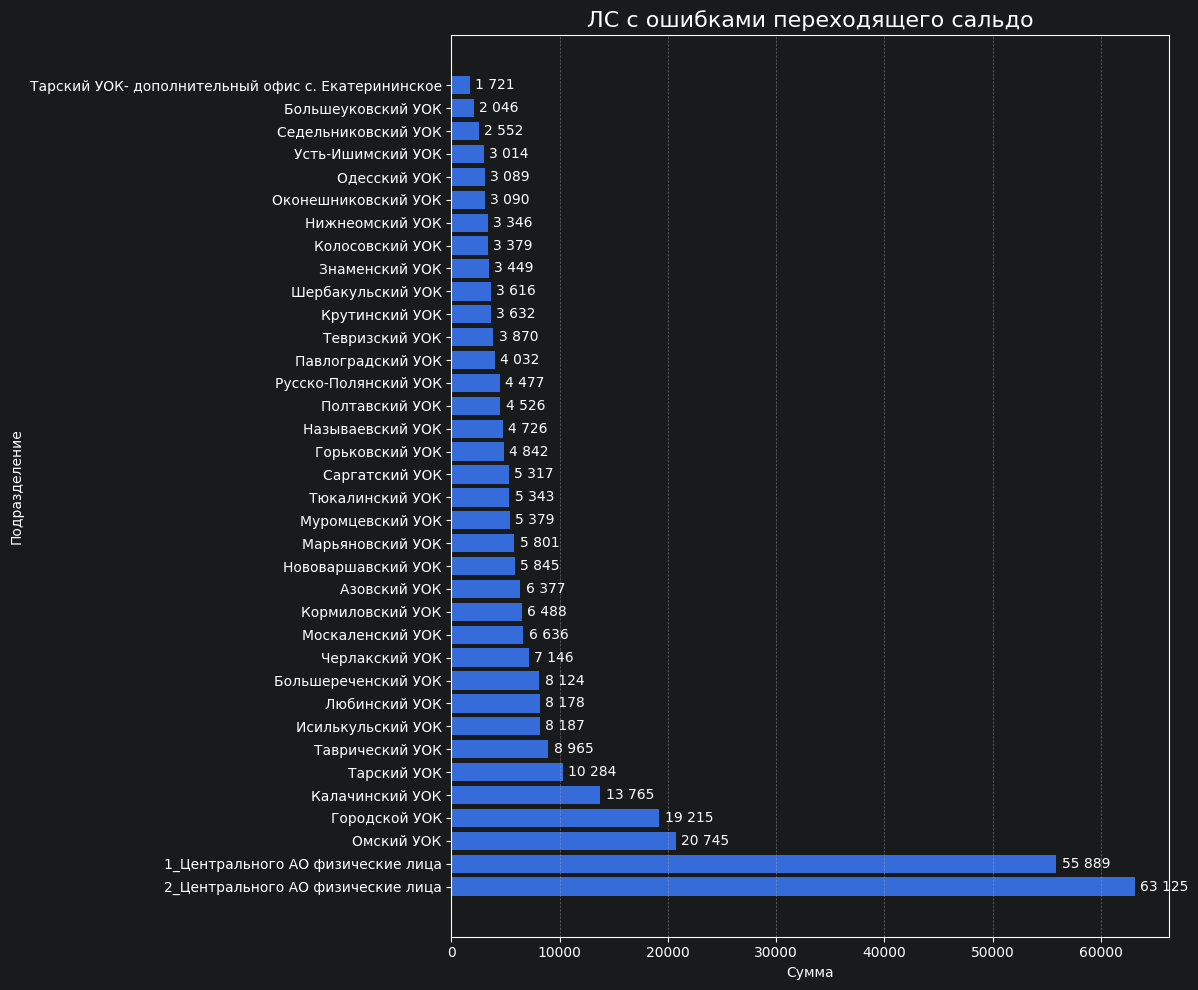

In [38]:
# Создаем график
plt.figure(figsize=(12, 10))

plt.barh(
    y=pereh_saldo_not_null_gr['rasch_podr'],
    width=pereh_saldo_not_null_gr['per_sal']
)

plt.title('ЛС с ошибками переходящего сальдо', fontsize=16)
plt.xlabel('Сумма')
plt.ylabel('Подразделение')

# Сетка
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Подписи значений
for i, value in enumerate(pereh_saldo_not_null_gr['per_sal']):
    plt.text(
        value + 500,
        i,
        f'{value:,.0f}'.replace(',', ' '),
        va='center'
    )

plt.tight_layout()
plt.show()

Теперь надо сравнить процент ошибок лицевых от общего количества лицевых в расчетном подразделении - пара числовое и числове значение.

In [39]:
#сначала группируем по районам все лицевые счета
pereh_saldo #.info()

,Номер договора,dz_beg_l,kz_beg_l,dz_end_l,kz_end_l,calc_l,dz_beg_c,kz_beg_c,dz_end_c,kz_end_c,calc_c,rasch_podr,Переходящее сальдо
0,01181010916,-482.40,-2872.54,-482.40,-2693.34,0.00,-482.40,-2872.54,-482.40,-2693.34,0.00,[1_Центрального АО физические лица],0.00
1,01181010927,4.45,0.00,133.10,0.00,128.65,4.45,0.00,133.10,0.00,128.65,[1_Центрального АО физические лица],128.65
2,01181010938,587.40,0.00,725.35,0.00,137.95,587.40,0.00,725.35,0.00,137.95,[1_Центрального АО физические лица],137.95
3,01181010949,689.75,-0.01,618.55,-0.01,-71.20,689.75,-0.01,618.55,-0.01,-71.20,[1_Центрального АО физические лица],-71.20
4,01181010950,890.00,-204.91,663.05,-204.91,-226.95,890.00,-204.91,663.05,-204.91,-226.95,[1_Центрального АО физические лица],-226.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501756,б/н_898891,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица],0.00
501757,б/н_924385,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица],0.00
501758,б/н_929650,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица],0.00
501759,б/н_937206,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,[2_Центрального АО физические лица],0.00


In [40]:
#перевод в строку
pereh_saldo['rasch_podr'] = (
    pereh_saldo['rasch_podr']
    .str[0]
)

#группируем по району
pereh_saldo_full = pereh_saldo.groupby('rasch_podr').agg(
    ls=('Номер договора', 'count')
).reset_index()

In [41]:
#Снова объединяем обе таблицы, чтобы сравнить процент лицевых с ошибочным переходящим сальдо
perc_ls = pd.merge(pereh_saldo_full, pereh_saldo_not_null_gr, on='rasch_podr', how='left')
perc_ls

perc_ls['Процент некорректных'] = (perc_ls['per_sal'] / perc_ls['ls']) * 100
perc_ls

,rasch_podr,ls,per_sal,Процент некорректных
0,1_Центрального АО физические лица,76862,55889,72.713434
1,2_Центрального АО физические лица,82844,63125,76.197431
2,Азовский УОК,9444,6377,67.524354
3,Большереченский УОК,11951,8124,67.977575
4,Большеуковский УОК,3443,2046,59.424920
5,Городской УОК,24953,19215,77.004769
6,Горьковский УОК,8302,4842,58.323296
7,Знаменский УОК,4997,3449,69.021413
8,Исилькульский УОК,16338,8187,50.110173
9,Калачинский УОК,18898,13765,72.838396


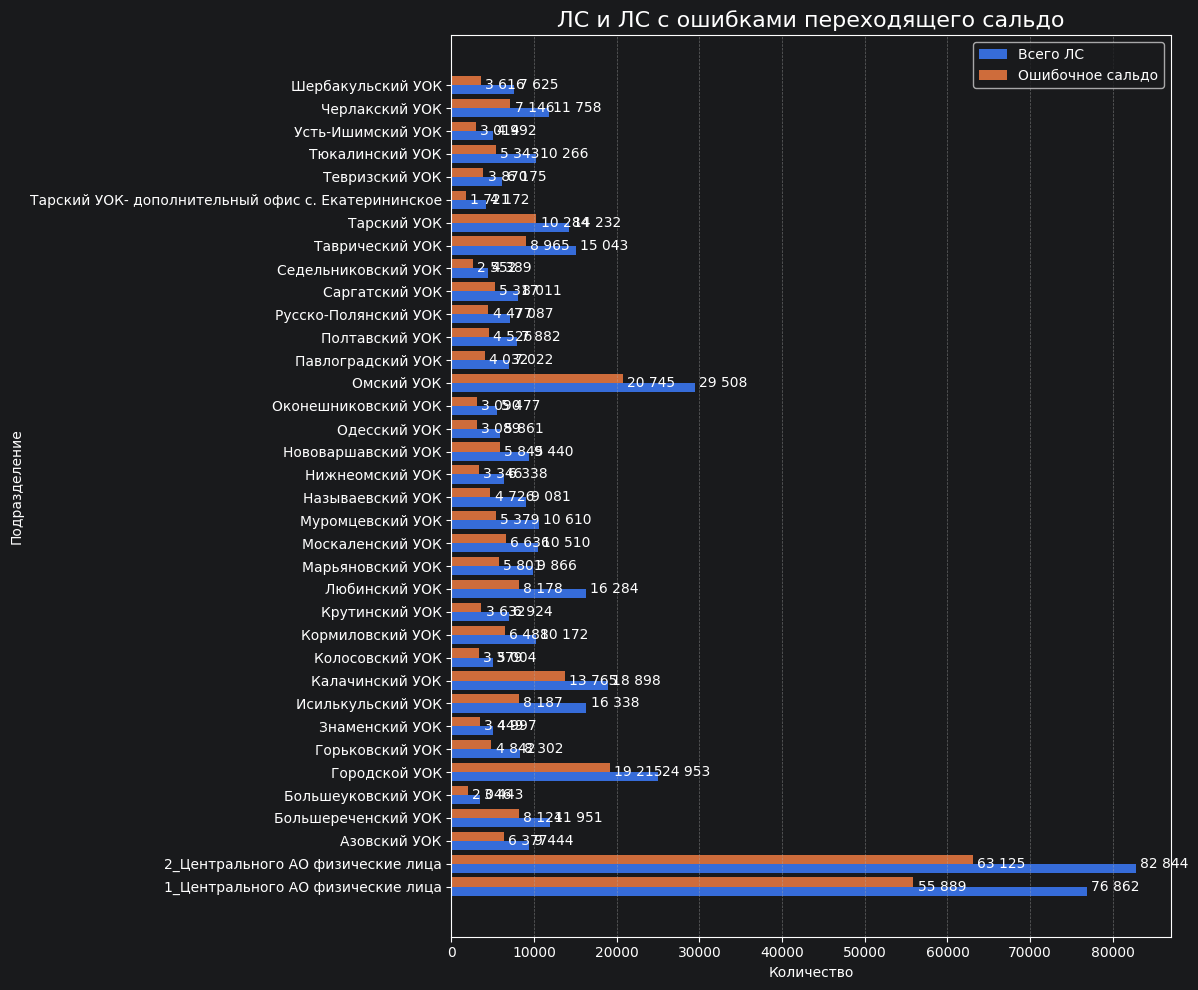

In [42]:
# Позиции по оси Y
y = np.arange(len(perc_ls))

# Высота столбцов
h = 0.4

plt.figure(figsize=(12, 10))

# Всего ЛС
plt.barh(
    y - h/2,
    perc_ls['ls'],
    height=h,
    label='Всего ЛС'
)

# ЛС с ошибками
plt.barh(
    y + h/2,
    perc_ls['per_sal'],
    height=h,
    label='Ошибочное сальдо'
)

# Подписи значений per_sal
for i, value in enumerate(perc_ls['per_sal']):
    plt.text(
        value + 500,
        i,
        f'{value:,.0f}'.replace(',', ' '),
        va='center'
    )

# Подписи значений ls
for i, value in enumerate(perc_ls['ls']):
    plt.text(
        value + 500,
        i,
        f'{value:,.0f}'.replace(',', ' '),
        va='center'
    )

# Названия подразделений
plt.yticks(y, perc_ls['rasch_podr'])

plt.title('ЛС и ЛС с ошибками переходящего сальдо', fontsize=16)
plt.xlabel('Количество')
plt.ylabel('Подразделение')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### Вывод по переходящему сальдо ###
Расчет проведен некорректно, либо не учтен большой процент оплат, поскольку большой процент ошибок с сальдо, с которым был закрыт расчетный период мая и открыт расчетный период июнь.

По практике скажу, что это данные промежуточного расчета. Данные взяты для закрепления знаний по модулю и понимаю работы с pandas и numpy.